# 6.5 Metadata Trial 006: Calibration Analysis

Purpose:
Check whether metadata risk scores are calibrated enough to be used as contextual risk evidence in fusion.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import (
    METADATA_SPLIT_MANIFEST_PATH,
    METADATA_TRIAL_001_MODEL_PATH,
    METADATA_TRIAL_006_CALIBRATION_FIGURE_PATH,
    METADATA_TRIAL_006_RESULTS_PATH,
)

from rural_stroke_assist.preprocessing.metadata import (
    prepare_metadata_modeling_frame,
    split_metadata_features_target,
)

from rural_stroke_assist.modeling.metadata_baselines import (
    load_metadata_model,
)

In [2]:
metadata_df = pd.read_csv(METADATA_SPLIT_MANIFEST_PATH)
metadata_model_df = prepare_metadata_modeling_frame(metadata_df)

test_df = metadata_model_df[metadata_model_df["split"] == "test"].copy()

X_test, y_test = split_metadata_features_target(test_df)

model = load_metadata_model(METADATA_TRIAL_001_MODEL_PATH)

risk_scores = model.predict_proba(X_test)[:, 1]

In [3]:
prob_true, prob_pred = calibration_curve(
    y_test,
    risk_scores,
    n_bins=10,
    strategy="quantile",
)

brier = brier_score_loss(y_test, risk_scores)

prob_true, prob_pred, brier

(array([0.        , 0.        , 0.        , 0.01298701, 0.05194805,
        0.02631579, 0.        , 0.03947368, 0.15584416, 0.20779221]),
 array([0.02258104, 0.03813917, 0.06139084, 0.0994195 , 0.17785374,
        0.29512415, 0.43602591, 0.59107868, 0.74783725, 0.86985162]),
 0.1813274952527165)

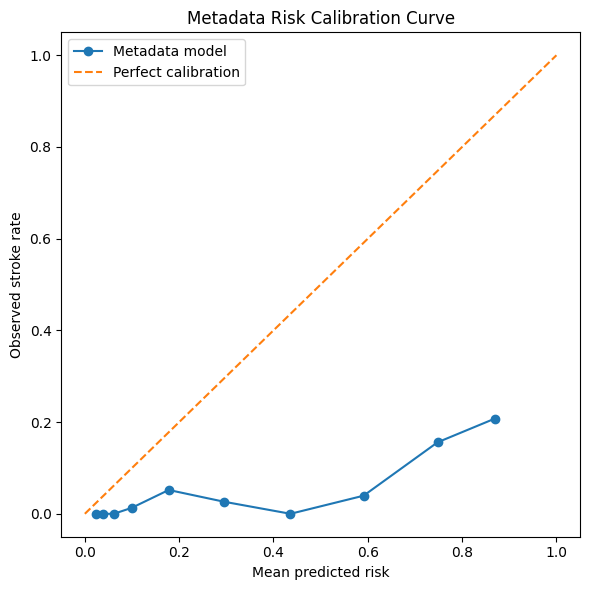

In [4]:
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Metadata model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted risk")
plt.ylabel("Observed stroke rate")
plt.title("Metadata Risk Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
METADATA_TRIAL_006_CALIBRATION_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Metadata model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted risk")
plt.ylabel("Observed stroke rate")
plt.title("Metadata Risk Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig(METADATA_TRIAL_006_CALIBRATION_FIGURE_PATH)
plt.close()

METADATA_TRIAL_006_CALIBRATION_FIGURE_PATH

WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/reports/figures/experiments/metadata_trial_006_calibration_curve.png')

In [6]:
report = f"""# Metadata Trial 006 Calibration Analysis

## Purpose

This experiment evaluates whether the metadata model's predicted probabilities behave like meaningful contextual risk scores.

## Results

- Brier score: {brier:.4f}

## Interpretation

Calibration is important because the metadata output will be used as a contextual risk score in the multimodal fusion layer.

The metadata score should not be interpreted as a direct acute stroke probability. It represents relative background risk based on demographic and clinical risk-factor variables.

## Decision

Accepted as a risk-score diagnostic artifact.

If calibration is poor, the fusion layer should treat the metadata output as a weak contextual signal rather than a precise probability.
"""

METADATA_TRIAL_006_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
METADATA_TRIAL_006_RESULTS_PATH.write_text(report, encoding="utf-8")

print(report)

# Metadata Trial 006 Calibration Analysis

## Purpose

This experiment evaluates whether the metadata model's predicted probabilities behave like meaningful contextual risk scores.

## Results

- Brier score: 0.1813

## Interpretation

Calibration is important because the metadata output will be used as a contextual risk score in the multimodal fusion layer.

The metadata score should not be interpreted as a direct acute stroke probability. It represents relative background risk based on demographic and clinical risk-factor variables.

## Decision

Accepted as a risk-score diagnostic artifact.

If calibration is poor, the fusion layer should treat the metadata output as a weak contextual signal rather than a precise probability.

